In [1]:
from google.colab import drive
import os
import gc
import random
import numpy as np

# Helps reduce CUDA memory fragmentation on Colab GPUs.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoModel, get_linear_schedule_with_warmup
from peft import LoraConfig, TaskType, get_peft_model

drive.mount('/content/drive')

SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.set_float32_matmul_precision("high")

CACHE_FILE = "/content/drive/MyDrive/CSI_Project/datasets/token_cache/tokens_maxlen512.pt"
CHECKPOINT_DIR = "/content/drive/MyDrive/CSI_Project/checkpoints"

Mounted at /content/drive


In [2]:
class SupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        if features.dim() != 2:
            raise ValueError("features must be 2D: [batch, hidden]")

        features = F.normalize(features, p=2, dim=1)
        batch_size = features.shape[0]
        labels = labels.contiguous().view(-1, 1)

        mask = torch.eq(labels, labels.T).float().to(features.device)
        logits = torch.matmul(features, features.T) / self.temperature
        logits = logits - logits.max(dim=1, keepdim=True).values.detach()

        logits_mask = torch.ones_like(mask)
        logits_mask.fill_diagonal_(0)
        mask = mask * logits_mask

        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-6)

        positives_per_row = mask.sum(1)
        mean_log_prob_pos = torch.where(
            positives_per_row > 0,
            (mask * log_prob).sum(1) / (positives_per_row + 1e-6),
            torch.zeros_like(positives_per_row),
        )
        return -mean_log_prob_pos.mean()


class RDropLoss(nn.Module):
    def __init__(self, alpha=4.0):
        super().__init__()
        self.alpha = alpha

    def forward(self, logits1, logits2, target, weights=None):
        ce_1 = F.cross_entropy(logits1, target, weight=weights)
        ce_2 = F.cross_entropy(logits2, target, weight=weights)
        ce_loss = 0.5 * (ce_1 + ce_2)

        kl_1 = F.kl_div(
            F.log_softmax(logits1, dim=-1),
            F.softmax(logits2, dim=-1),
            reduction="batchmean",
        )
        kl_2 = F.kl_div(
            F.log_softmax(logits2, dim=-1),
            F.softmax(logits1, dim=-1),
            reduction="batchmean",
        )
        kl_loss = 0.5 * (kl_1 + kl_2)
        return ce_loss + self.alpha * kl_loss

In [4]:
class VulnerabilityDataset(Dataset):
    def __init__(self, cache: dict, split: str):
        indices = [i for i, s in enumerate(cache["split_origins"]) if s == split]
        self.input_ids = cache["input_ids"][indices]
        self.attention_mask = cache["attention_mask"][indices]
        self.cwe_labels = cache["cwe_labels"][indices]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "cwe_label": self.cwe_labels[idx],
        }


if os.path.exists(CACHE_FILE):
    cache = torch.load(CACHE_FILE, map_location="cpu")

    train_ds = VulnerabilityDataset(cache, split="train")
    val_ds = VulnerabilityDataset(cache, split="val")

    counts = np.bincount(train_ds.cwe_labels.numpy(), minlength=8).astype(float)
    counts = np.clip(counts, a_min=1.0, a_max=None)
    CLASS_WEIGHTS = torch.tensor(len(train_ds) / (8 * counts), dtype=torch.float, device=DEVICE)

    sample_weights = torch.tensor(1.0 / counts[train_ds.cwe_labels.numpy()], dtype=torch.double)
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_ds), replacement=True)

    NUM_WORKERS = min(2, os.cpu_count() or 1)
    PIN_MEMORY = DEVICE == "cuda"

    train_loader = DataLoader(
        train_ds,
        batch_size=2,
        sampler=sampler,
        drop_last=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=1,
        shuffle=False,
        drop_last=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
    )

    # Kept for backward compatibility with earlier notebook cells.
    test_loader = train_loader

    print(f"CLASS_WEIGHTS ready on {DEVICE}: {CLASS_WEIGHTS.shape}")
    print(f"Train samples: {len(train_ds)} | Val samples: {len(val_ds)}")
else:
    print("CACHE_FILE path is incorrect")

CLASS_WEIGHTS ready on cuda: torch.Size([8])
Train samples: 12994 | Val samples: 1528


In [5]:
class GraphCodeBERTLoRACWEModel(nn.Module):
    def __init__(self, model_name="microsoft/graphcodebert-base", num_cwe_classes=8, class_weights=None):
        super().__init__()

        encoder = AutoModel.from_pretrained(model_name)
        if hasattr(encoder, "gradient_checkpointing_enable"):
            encoder.gradient_checkpointing_enable()
        if hasattr(encoder.config, "use_cache"):
            encoder.config.use_cache = False

        lora_cfg = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=16,
            lora_alpha=32,
            target_modules=["query", "key", "value"],
        )
        self.encoder = get_peft_model(encoder, lora_cfg)

        hidden = self.encoder.config.hidden_size
        self.cwe_head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Linear(hidden // 2, num_cwe_classes),
        )
        self.register_buffer("weights", class_weights)

    def forward(self, input_ids, attention_mask):
        enc = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=False,
        )
        features = enc.last_hidden_state[:, 0, :]
        logits = self.cwe_head(features)
        return {"logits": logits, "features": features}


# Quick sanity test for SCL and R-Drop on one batch.
if "train_loader" not in globals():
    raise RuntimeError("train_loader is not defined. Run the dataset/cache cell first.")

model = GraphCodeBERTLoRACWEModel(class_weights=CLASS_WEIGHTS)

# Always align model + losses to a single runtime device.
runtime_device = DEVICE
try:
    model = model.to(runtime_device)
except torch.cuda.OutOfMemoryError:
    runtime_device = "cpu"
    model = model.to(runtime_device)

scl_criterion = SupervisedContrastiveLoss().to(runtime_device)
rdrop_criterion = RDropLoss().to(runtime_device)
class_weights_runtime = CLASS_WEIGHTS.to(runtime_device)

model.train()
batch = next(iter(train_loader))
ids = batch["input_ids"].to(runtime_device, non_blocking=(runtime_device == "cuda"))
mask = batch["attention_mask"].to(runtime_device, non_blocking=(runtime_device == "cuda"))
labels = batch["cwe_label"].to(runtime_device, non_blocking=(runtime_device == "cuda"))

with torch.no_grad():
    res1 = model(ids, mask)
    res2 = model(ids, mask)
    loss_scl = scl_criterion(
        torch.cat([res1["features"], res2["features"]], dim=0),
        torch.cat([labels, labels], dim=0),
    )
    loss_rdrop = rdrop_criterion(res1["logits"], res2["logits"], labels, weights=class_weights_runtime)

print(f"Sanity device: {runtime_device}")
print(f"SCL Loss: {loss_scl.item():.4f}")
print(f"R-Drop Loss: {loss_rdrop.item():.4f}")

# Cleanup temporary tensors from sanity test.
del batch, ids, mask, labels, res1, res2, loss_scl, loss_rdrop
if runtime_device == "cuda":
    torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/539 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: microsoft/graphcodebert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Sanity device: cuda
SCL Loss: 1.2530
R-Drop Loss: 2.1614


In [11]:
import torch.amp as amp
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import time
import gc

if "train_ds" not in globals() or "val_ds" not in globals():
    raise RuntimeError("train_ds/val_ds are not defined. Run the dataset/cache cell first.")

checkpoint_dir = Path(CHECKPOINT_DIR)
checkpoint_dir.mkdir(parents=True, exist_ok=True)
LATEST_CHECKPOINT = checkpoint_dir / "latest.pt"
BEST_CHECKPOINT = checkpoint_dir / "best.pt"

# Configuration constants
TRAIN_BATCH_SIZE = 2
VAL_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 1
NUM_EPOCHS = 22
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
SCL_WEIGHT = 0.2
USE_MIXED_PRECISION = DEVICE == "cuda"

train_loader = DataLoader(
    train_ds,
    batch_size=TRAIN_BATCH_SIZE,
    sampler=sampler,
    drop_last=True,
    num_workers=2,
    pin_memory=(DEVICE == "cuda"),
    persistent_workers=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=2,
    pin_memory=(DEVICE == "cuda"),
    persistent_workers=True,
)

# Re-initialize model
model = GraphCodeBERTLoRACWEModel(class_weights=CLASS_WEIGHTS).to(DEVICE)

# Aggressively disable gradient checkpointing on all modules
print("Disabling gradient checkpointing...")
for module in model.modules():
    # Direct attribute
    if hasattr(module, "gradient_checkpointing"):
        module.gradient_checkpointing = False
    # Method call
    if hasattr(module, "gradient_checkpointing_disable"):
        try:
            module.gradient_checkpointing_disable()
        except Exception as e:
            pass
    # Config level
    if hasattr(module, "config"):
        if hasattr(module.config, "gradient_checkpointing"):
            module.config.gradient_checkpointing = False
        if hasattr(module.config, "use_cache"):
            module.config.use_cache = False

# Double-check PEFT base model
if hasattr(model.encoder, "base_model"):
    if hasattr(model.encoder.base_model, "gradient_checkpointing"):
        model.encoder.base_model.gradient_checkpointing = False
    if hasattr(model.encoder.base_model, "config"):
        model.encoder.base_model.config.gradient_checkpointing = False
        model.encoder.base_model.config.use_cache = False

print("✓ Gradient checkpointing disabled")

# Loss criteria
scl_criterion = SupervisedContrastiveLoss(temperature=0.09).to(DEVICE)
rdrop_criterion = RDropLoss(alpha=3.0).to(DEVICE)

# Optimizer & Scheduler
steps_per_epoch = len(train_loader)
total_steps = (steps_per_epoch // GRADIENT_ACCUMULATION_STEPS) * NUM_EPOCHS
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

print(f"Total steps: {total_steps}")
print(f"Warmup steps: {int(0.1 * total_steps)}")

# Utilities
def move_optimizer_state_to_device(optimizer_obj, device):
    for state in optimizer_obj.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(device)

def save_checkpoint(path, epoch, best_val_macro_f1, history):
    ckpt = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_macro_f1": best_val_macro_f1,
        "loss_history": history,
    }
    torch.save(ckpt, path)
    print(f"Saved checkpoint to {path}")

def load_checkpoint(path):
    default_history = {
        "train_loss": [],
        "train_scl": [],
        "train_rdrop": [],
        "val_acc": [],
        "val_macro_f1": [],
    }
    if not path.exists():
        return 0, -1.0, default_history
    ckpt = torch.load(path, map_location="cpu")
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    if DEVICE == "cuda":
        move_optimizer_state_to_device(optimizer, DEVICE)
    return (
        ckpt.get("epoch", 0) + 1,
        ckpt.get("best_val_macro_f1", -1.0),
        ckpt.get("loss_history", default_history),
    )

def run_validation():
    model.eval()
    preds, labels_all = [], []
    with torch.inference_mode():
        for batch in val_loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            labels = batch["cwe_label"].to(DEVICE)
            with amp.autocast("cuda", enabled=USE_MIXED_PRECISION):
                logits = model(ids, mask)["logits"]
            preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
            labels_all.extend(labels.cpu().tolist())
    return accuracy_score(labels_all, preds), f1_score(
        labels_all, preds, average="macro", zero_division=0
    )

# Load checkpoint if exists
start_epoch, best_val_macro_f1, loss_history = load_checkpoint(LATEST_CHECKPOINT)
scaler = amp.GradScaler("cuda", enabled=USE_MIXED_PRECISION)

print(f"\nStarting from epoch {start_epoch + 1}/{NUM_EPOCHS}")
print(f"Best val F1 so far: {best_val_macro_f1:.4f}")
print(f"Device: {DEVICE}")


# ============================================================================
# CELL 3: Main Training Loop with Live Progress
# ============================================================================

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0
    total_scl = 0.0
    total_rdrop = 0.0
    used_batches = 0
    skipped_oom = 0

    pbar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}",
        leave=True,
    )

    for step, batch in pbar:
        ids = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labels = batch["cwe_label"].to(DEVICE)

        try:
            with amp.autocast("cuda", enabled=USE_MIXED_PRECISION):
                # Two forward passes for R-Drop
                out1 = model(ids, mask)
                out2 = model(ids, mask)

                # SCL loss
                l_scl = scl_criterion(
                    torch.cat([out1["features"], out2["features"]], dim=0),
                    torch.cat([labels, labels], dim=0),
                )

                # R-Drop loss
                l_rdrop = rdrop_criterion(
                    out1["logits"],
                    out2["logits"],
                    labels,
                    weights=CLASS_WEIGHTS,
                )

                # Combined loss
                raw_loss = l_rdrop + SCL_WEIGHT * l_scl
                loss = raw_loss / GRADIENT_ACCUMULATION_STEPS

            scaler.scale(loss).backward()
            total_loss += raw_loss.item()
            total_scl += l_scl.item()
            total_rdrop += l_rdrop.item()
            used_batches += 1

            # Gradient accumulation step
            if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

            # Update progress bar
            pbar.set_postfix({
                "loss": f"{raw_loss.item():.4f}",
                "rdrop": f"{l_rdrop.item():.4f}",
                "scl": f"{l_scl.item():.4f}",
                "lr": f"{scheduler.get_last_lr()[0]:.2e}",
            })

        except torch.cuda.OutOfMemoryError:
            skipped_oom += 1
            optimizer.zero_grad(set_to_none=True)
            torch.cuda.empty_cache()
            pbar.set_postfix({"OOM": skipped_oom})

    # Validation
    val_acc, val_macro_f1 = run_validation()

    # Record history
    loss_history["train_loss"].append(total_loss / used_batches)
    loss_history["train_scl"].append(total_scl / used_batches)
    loss_history["train_rdrop"].append(total_rdrop / used_batches)
    loss_history["val_acc"].append(val_acc)
    loss_history["val_macro_f1"].append(val_macro_f1)

    # Save latest checkpoint
    save_checkpoint(LATEST_CHECKPOINT, epoch, best_val_macro_f1, loss_history)

    # Save best checkpoint
    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        save_checkpoint(BEST_CHECKPOINT, epoch, best_val_macro_f1, loss_history)
        print(f"✓ New best F1: {val_macro_f1:.4f}")

    print(
        f"\n[Epoch {epoch + 1}] "
        f"Train: {total_loss / used_batches:.4f} | "
        f"RDrop: {total_rdrop / used_batches:.4f} | "
        f"SCL: {total_scl / used_batches:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_macro_f1:.4f} | "
        f"OOM Skip: {skipped_oom}\n"
    )

    gc.collect()
    torch.cuda.empty_cache()

print("Training complete.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: microsoft/graphcodebert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Disabling gradient checkpointing...
✓ Gradient checkpointing disabled
Total steps: 142934
Warmup steps: 14293

Starting from epoch 22/22
Best val F1 so far: 0.6331
Device: cuda


Epoch 22/22:   0%|          | 0/6497 [00:00<?, ?it/s]

KeyboardInterrupt: 

### SCL Analysis & Logging
This section handles the visualization of SCL impacts and logs the experiments to your project folder.

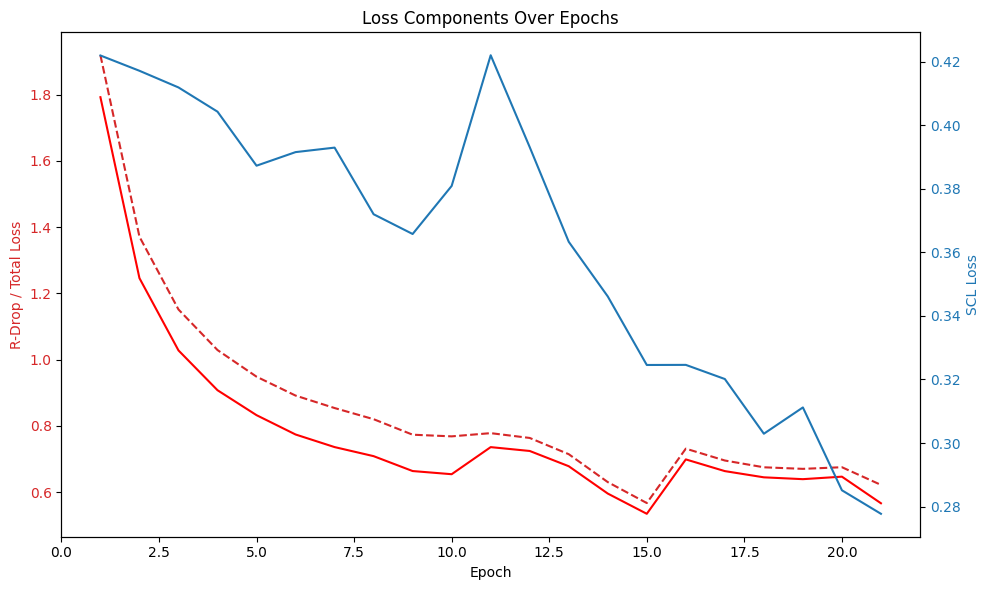

In [12]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('R-Drop / Total Loss', color='tab:red')
    ax1.plot(epochs, history['train_loss'], label='Total Loss', color='tab:red', linestyle='--')
    ax1.plot(epochs, history['train_rdrop'], label='R-Drop Loss', color='red')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax1.twinx()
    ax2.set_ylabel('SCL Loss', color='tab:blue')
    ax2.plot(epochs, history['train_scl'], label='SCL Loss', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    plt.title('Loss Components Over Epochs')
    fig.tight_layout()
    plt.show()

if 'loss_history' in globals():
    plot_training_history(loss_history)

In [13]:
import pandas as pd
from datetime import datetime

LOG_FILE = "/content/drive/MyDrive/CSI_Project/experiment_log.csv"

def log_experiment_results(metrics_dict):
    """Appends a dictionary of hyperparameters and results to a CSV file."""
    metrics_dict['timestamp'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    df = pd.DataFrame([metrics_dict])

    if not os.path.exists(LOG_FILE):
        df.to_csv(LOG_FILE, index=False)
    else:
        df.to_csv(LOG_FILE, mode='a', header=False, index=False)
    print(f"Results logged to {LOG_FILE}")

# Example usage (to be run after training completes or from best checkpoint):
current_run_stats = {
    "model": "GraphCodeBERT-LoRA",
    "scl_weight": SCL_WEIGHT,
    "temperature": 0.07,
    "best_val_f1": best_val_macro_f1,
    "learning_rate": LEARNING_RATE,
    "batch_size": TRAIN_BATCH_SIZE
}

# Uncomment to log the current state:
# log_experiment_results(current_run_stats)